<!--<badge>--><a href="https://colab.research.google.com/github/JoeChen322/Fintech/blob/main/classification-models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->


# Investment Product Classification: Client Profiling & Recommendation Engine

This notebook implements a comprehensive machine learning pipeline to classify clients based on their investment profile and recommend suitable financial products. The workflow encompasses data cleaning, outlier detection, feature engineering, and model training using multiple classifiers.

## Objective

Build accurate binary classifiers for two investment targets:

- **Income Investment**: Investment in income-generating products
- **Accumulation Investment**: Investment in wealth accumulation/growth products

## Workflow

1. Load and explore client dataset
2. Clean and validate data
3. Detect and analyze outliers
4. Transform highly skewed features (Income, Wealth)
5. Engineer domain-specific features
6. Train and tune multiple classifiers
7. Benchmark and compare models


## Table of Contents

1. [Imports & Dependencies](#1-imports--dependencies)
2. [Configuration & Data Loading](#2-configuration--data-loading)
3. [Data Cleaning Functions](#3-data-cleaning-functions)
4. [Outlier Detection & Analysis](#4-outlier-detection--analysis)
5. [Data Transformation](#5-data-transformation)
6. [Feature Engineering](#6-feature-engineering)
7. [Model Training & Evaluation Framework](#7-model-training--evaluation-framework)
   - [7.1 ML Pipelines Setup](#71-ml-pipelines-setup)
8. [Model Training & Hyperparameter Tuning](#8-model-training--hyperparameter-tuning)
   - [8.1 SVM & Naive Bayes](#81-svm--naive-bayes)
   - [8.2 XGBoost](#82-xgboost)
   - [8.3 K-Nearest Neighbors (KNN)](#83-k-nearest-neighbors-knn)
   - [8.4 Random Forest](#84-random-forest)
9. [Model Benchmark & Comparison](#9-model-benchmark--comparison)


# 1. Imports & Dependencies


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import gdown
from typing import List, Dict, Optional, Tuple
from dataclasses import dataclass
from scipy import stats
from scipy.stats import chi2_contingency, skew, shapiro, normaltest

# Data preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

# Model selection and evaluation
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_validate,
)
from sklearn.base import clone

# Classifiers
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)


# Feature selection
from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    RFE,
    mutual_info_classif,
)

# Pipeline
from sklearn.pipeline import Pipeline

# Other utilities
import xgboost as xgb
from tabulate import tabulate


In [2]:
url = "https://drive.google.com/uc?id=1TiR645keulkG4pONLpVn-bO4elNBtNpX"
file_path = "Dataset2_Needs.xls"
gdown.download(url, file_path, quiet=False)
needs_df = pd.read_excel(file_path, sheet_name="Needs")
products_df = pd.read_excel(file_path, sheet_name="Products")
metadata_df = pd.read_excel(file_path, sheet_name="Metadata")

print("Needs shape:", needs_df.shape)
print("Products shape:", products_df.shape)
print("Metadata shape:", metadata_df.shape)


Downloading...
From: https://drive.google.com/uc?id=1TiR645keulkG4pONLpVn-bO4elNBtNpX
To: /Users/pengrao/Workspace/Fintech/Dataset2_Needs.xls
100%|██████████| 428k/428k [00:00<00:00, 8.31MB/s]


Needs shape: (5000, 10)
Products shape: (11, 3)
Metadata shape: (29, 2)


# 2. Configuration & Data Loading


The next cells aim to load the Excel workbook and separate the sheets into:

- the main client dataset : needs_df
- the products catalogue : products_df
- the metadata table : metadata_df

Initially, we will analyze the need_df table containing the data of the different clients. We are going to inspect structure and variable meaning of this specific table.


In [3]:
needs_df = pd.read_excel("Dataset2_Needs.xls", sheet_name="Needs")
products_df = pd.read_excel("Dataset2_Needs.xls", sheet_name="Products")

# The metadata retrieved is that relating to the needs_df database
metadata_df = pd.read_excel("Dataset2_Needs.xls", sheet_name="Metadata", nrows=11)

# We delete the first line, which doesn't serve much purpose
metadata_df = metadata_df[metadata_df["Metadata"] != "Clients"]

# We remove any potentially unnecessary spaces at the beginning and end of each column name.
# (An unwanted space was present in "income ")
needs_df.columns = needs_df.columns.str.strip()
products_df.columns = products_df.columns.str.strip()
metadata_df.columns = metadata_df.columns.str.strip()

# List of categorical columns in the dataset:
CATEGORICAL_COLS = ["Gender"]

# List of numeric columns in the dataset:
NUMERIC_COLS = [
    "Age",
    "FamilyMembers",
    "FinancialEducation",
    "RiskPropensity",
    "Income",
    "Wealth",
]

# List of target columns in the dataset:
TARGET_COLS = ["IncomeInvestment", "AccumulationInvestment"]

# Value mapping: introduces dictionaries to convert numeric codes into readable labels
VALUE_MAPS: Dict[str, Dict[int, str]] = {
    "Gender": {0: "Male", 1: "Female"},
    "AccumulationInvestment": {0: "Low propensity", 1: "High propensity"},
    "IncomeInvestment": {0: "Low propensity", 1: "High propensity"},
}

needs_df.head()


,ID,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth,IncomeInvestment,AccumulationInvestment
0,1,60,0,2,0.228685,0.233355,68.181525,53.260067,0,1
1,2,78,0,2,0.358916,0.170911,21.807595,135.550048,1,0
2,3,33,1,2,0.317515,0.249703,23.252747,66.303678,0,1
3,4,69,1,4,0.767685,0.654597,166.189034,404.997689,1,1
4,5,58,0,3,0.429719,0.349039,21.186723,58.911930,0,0


In [4]:
products_df.head()


,IDProduct,Type,Risk
0,1,1,0.55
1,2,0,0.30
2,3,0,0.12
3,4,0,0.44
4,5,1,0.41


In [5]:
metadata_df.head(20)


,Metadata,Unnamed: 1
1,ID,Numerical ID
2,Age,"Age, in years"
3,Gender,"Gender (Female = 1, Male = 0)"
4,FamilyMembers,Number of components
5,FinancialEducation,Normalized level of Financial Education (estim...
6,RiskPropensity,Normalized Risk propensity from MIFID profile
7,Income,Income (thousands of euros); estimate
8,Wealth,Wealth (thousands of euros); sum of investment...
9,IncomeInvestment,Boolean variable for Income investment; 1 = Hi...
10,AccumulationInvestment,Boolean variable for Accumulation/growth inves...


# 3. Data Cleaning Functions


Define data validation and preprocessing functions.


In [6]:
# Dataclass used to store the cleaned and prepared dataset
@dataclass
class PreparedFeatures:
    # Final prepared dataset of features after preprocessing
    X: pd.DataFrame

    # Metadata associated with this dataset (feature descriptions, etc.)
    features_metadata_df: pd.DataFrame

    # List of numerical columns kept in the dataset
    numeric_cols: List[str]

    # List of categorical columns kept in the dataset
    categorical_cols: List[str]

    # Columns that have zero variance
    removed_zero_variance_cols: List[str]

    # Columns with very low variance
    near_zero_variance_cols: List[str]

    # Audit log describing the preprocessing steps that were applied
    audit_lines: List[str]


@dataclass
class PreparedTargets:
    # Final prepared dataset of targets values after preprocessing
    Y: pd.DataFrame

    # Metadata associated with this dataset (feature descriptions, etc.)
    targets_metadata_df: pd.DataFrame

    # List of indexes retained in the dataset after removing rows with missing IncomeInvestment and AccumulationInvest values
    kept_index: pd.Index

    # number of lines with NaN value
    dropped_rows_missing_target: int

    # Audit log describing the preprocessing steps that were applied
    audit_lines: List[str]


@dataclass
class OutlierDetectionResult:
    # Dataset of features after potentially removing the outliers
    X_inliers: pd.DataFrame

    # Dataset of target values after potentially removing the outliers
    Y_inliers: pd.DataFrame

    # Column associating 1 if the point is considered normal, -1 otherwise
    full_outlier_labels: pd.Series

    # Anomaly score for each observation
    full_anomaly_scores: pd.Series

    # Number of outliers detected
    outlier_count: int

    # Porportion of outliers
    outlier_rate: float

    # Audit log describing the preprocessing steps that were applied
    audit_lines: List[str]


The following code allows you to create two new datasets, one containing all the features and customer data, the other containing the target variables


In [7]:
def split_features_and_targets(
    data: pd.DataFrame, target_cols: List[str] = TARGET_COLS
) -> Tuple[pd.DataFrame, pd.DataFrame]:

    Y = data[target_cols].copy()

    drop_cols = target_cols.copy()
    X = data.drop(columns=drop_cols, errors="ignore").copy()

    return X, Y


In [8]:
X, Y = split_features_and_targets(data=needs_df)

targets_metadata_df = metadata_df[
    metadata_df["Metadata"].isin(TARGET_COLS)
].reset_index(drop=True)

features_metadata_df = metadata_df[
    ~metadata_df["Metadata"].isin(TARGET_COLS)
].reset_index(drop=True)


In [9]:
features_metadata_df.head()


,Metadata,Unnamed: 1
0,ID,Numerical ID
1,Age,"Age, in years"
2,Gender,"Gender (Female = 1, Male = 0)"
3,FamilyMembers,Number of components
4,FinancialEducation,Normalized level of Financial Education (estim...


In [10]:
targets_metadata_df.head()


,Metadata,Unnamed: 1
0,IncomeInvestment,Boolean variable for Income investment; 1 = Hi...
1,AccumulationInvestment,Boolean variable for Accumulation/growth inves...


In [11]:
X.head()


,ID,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth
0,1,60,0,2,0.228685,0.233355,68.181525,53.260067
1,2,78,0,2,0.358916,0.170911,21.807595,135.550048
2,3,33,1,2,0.317515,0.249703,23.252747,66.303678
3,4,69,1,4,0.767685,0.654597,166.189034,404.997689
4,5,58,0,3,0.429719,0.349039,21.186723,58.911930


In [12]:
Y.head()


,IncomeInvestment,AccumulationInvestment
0,0,1
1,1,0
2,0,1
3,1,1
4,0,0


In [13]:
# Detect different forms of missing values and replaces them with np.nan
def normalize_missing_tokens(df: pd.DataFrame) -> pd.DataFrame:
    tokens = {"", " ", "NA", "N/A", "na", "n/a", "null", "None", "none", "-", "--"}
    out = df.copy()
    for col in out.columns:
        if out[col].dtype == object:
            out[col] = out[col].replace(list(tokens), np.nan)
    return out


# Detect whether a feature has near-zero variance
def detect_near_zero_variance(series: pd.Series) -> bool:
    s = series.dropna()
    counts = s.value_counts()

    # Compute the ratio between the most frequent and second most frequent values
    freq_ratio = counts.iloc[0] / max(counts.iloc[1], 1)

    # Compute the ratio between the number of different values and the total number of observations used to measure the diversity of values in this feature
    pct_unique = s.nunique() / len(s)
    return (freq_ratio >= 20) and (pct_unique <= 0.10)


def clean_and_audit_data(
    data: pd.DataFrame,
    features_metadata_df: pd.DataFrame,
    categorical_cols: List[str] = CATEGORICAL_COLS,
    numeric_cols: List[str] = NUMERIC_COLS,
    value_maps: Dict[str, Dict[int, str]] = VALUE_MAPS,
) -> PreparedFeatures:
    # Initialize an audit log to keep track of all cleaning steps
    audit_lines: List[str] = []

    # Create a working copy of the dataset and standardize missing-value tokens
    df = normalize_missing_tokens(data.copy())

    # Start audit report
    audit_lines.append("DATA AUDIT")
    audit_lines.append("=" * 80)
    audit_lines.append(f"Initial X shape (dataset of features): {df.shape}")

    # Remove fully duplicated rows
    exact_dupes = int(df.duplicated().sum())
    if exact_dupes > 0:
        df = df.drop_duplicates().copy()
    audit_lines.append(f"Exact duplicate rows removed: {exact_dupes}")

    # Remove duplicated IDs, keeping only the first occurrence
    duplicate_ids = int(df["ID"].duplicated().sum())
    if duplicate_ids > 0:
        df = df.drop_duplicates(subset=["ID"], keep="first").copy()
    audit_lines.append(f"Duplicate IDs removed: {duplicate_ids}")

    # Delete the columns 'ID' that doesn't contains any usefull information for the clustering
    df = df.drop(columns=["ID"])

    # Identify categorical columns
    # Identify numeric columns by excluding ID and categorical columns
    categorical_cols = [c for c in categorical_cols if c in df.columns]
    numeric_cols = [c for c in numeric_cols if c in df.columns]

    # Convert columns to numeric (for instance "2" to 2). Invalid values become NaN
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Validate categorical codes against allowed values defined in VALUE_MAPS
    # All invalid values become: NaN
    audit_lines.append("Invalid categorical codes replaced with missing values:")
    for col in categorical_cols:
        allowed = set(value_maps[col].keys()) if col in value_maps else None
        invalid_mask = ~df[col].isin(allowed) & df[col].notna()
        invalid_count = int(invalid_mask.sum())
        if invalid_count > 0:
            df.loc[invalid_mask, col] = np.nan
        audit_lines.append(f"  - {col}: {invalid_count}")

    # Record missing values before imputation
    audit_lines.append("Missing values before imputation:")
    for col, val in df.isna().sum().items():
        audit_lines.append(f"  - {col}: {int(val)}")

    # Impute missing numeric values with the median
    for col in numeric_cols:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())

    # Impute missing categorical values with the most frquence value taken
    # If this value doesn't exist, it uses a fallback value defined from the allowed categories (VALUE_MAPS)
    # Finaly convert the entire column to ensure a consistent format usable by algorithms
    for col in categorical_cols:
        if df[col].isna().any():
            mode_value = df[col].mode(dropna=True)
            fallback = sorted(value_maps[col].keys())[0]
            fill_value = int(mode_value.iloc[0]) if not mode_value.empty else fallback
            df[col] = df[col].fillna(fill_value)

        df[col] = df[col].astype(int)

    # Record missing values after imputation
    audit_lines.append("Missing values after imputation:")
    for col, val in df.isna().sum().items():
        audit_lines.append(f"  - {col}: {int(val)}")

    # Detect zero-variance and near-zero-variance features
    removed_zero_variance_cols: List[str] = []
    near_zero_variance_cols: List[str] = []

    # Iterate through the columns
    # Save them that contained only a single value (and therefore having a variance of 0) in the list removed_zero_variance_cols
    # Save them that detecte as "near zero variance" in the list near_zero_variance_cols
    for col in df.columns:
        if df[col].nunique(dropna=False) <= 1:
            removed_zero_variance_cols.append(col)
        elif detect_near_zero_variance(df[col]):
            near_zero_variance_cols.append(col)

    # Remove zero-variance columns
    if removed_zero_variance_cols:
        df = df.drop(columns=removed_zero_variance_cols).copy()

    # Remove near-zero-variance columns
    if near_zero_variance_cols:
        df = df.drop(columns=near_zero_variance_cols).copy()

    audit_lines.append(
        "Zero-variance columns removed: "
        + (
            ", ".join(removed_zero_variance_cols)
            if removed_zero_variance_cols
            else "none"
        )
    )
    audit_lines.append(
        "Near-zero-variance columns removed: "
        + (", ".join(near_zero_variance_cols) if near_zero_variance_cols else "none")
    )

    # Update column lists after removing zero-variance and near-zero-variance columns
    categorical_cols = [
        c for c in categorical_cols if c not in removed_zero_variance_cols
    ]
    numeric_cols = [c for c in numeric_cols if c not in removed_zero_variance_cols]

    # Compute absolute correlation matrix for numeric features
    if numeric_cols:
        corr = df[numeric_cols].corr().abs()
        high_corr = []

        for i in range(len(corr.columns)):
            for j in range(i + 1, len(corr.columns)):
                if corr.iloc[i, j] >= 0.85:
                    high_corr.append(
                        (corr.index[i], corr.columns[j], float(corr.iloc[i, j]))
                    )

        if high_corr:
            audit_lines.append(
                "High-correlation numeric pairs flagged (not auto-removed):"
            )
            for a, b, r in high_corr:
                audit_lines.append(f"  - {a} vs {b}: {r:.3f}")
        else:
            audit_lines.append(
                "High-correlation numeric pairs flagged: none above 0.85"
            )
    else:
        audit_lines.append(
            "High-correlation numeric pairs flagged: no numeric columns available"
        )

    audit_lines.append(f"Final shape after cleaning: {df.shape}")

    return PreparedFeatures(
        X=df,
        features_metadata_df=features_metadata_df,
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        removed_zero_variance_cols=removed_zero_variance_cols,
        near_zero_variance_cols=near_zero_variance_cols,
        audit_lines=audit_lines,
    )


Binary target processing :


In [14]:
def prepare_binary_targets(
    data: pd.DataFrame,
    targets_metadata_df: pd.DataFrame,
    target_cols: List[str] = TARGET_COLS,
    value_maps: Dict[str, Dict[int, str]] = VALUE_MAPS,
) -> PreparedTargets:
    # Initialize an audit log to keep track of all cleaning steps
    audit_lines: List[str] = []

    # Create a working copy of the dataset and standardize missing-value tokens
    df = normalize_missing_tokens(data.copy())

    # Start audit report
    audit_lines.append("DATA AUDIT")
    audit_lines.append("=" * 80)
    audit_lines.append(f"Initial Y shape (dataset of targets): {df.shape}")

    audit_lines.append(f"Invalid target codes replaced with missing values")
    for col in df.columns:
        # Convert columns to numeric (for instance "2" to 2). Invalid values become NaN
        df[col] = pd.to_numeric(df[col], errors="coerce")

        # Validate values against allowed values defined in VALUE_MAPS
        # All invalid values become: NaN
        allowed = set(value_maps[col].keys())
        invalid_mask = ~df[col].isin(allowed) & df[col].notna()
        invalid_count = int(invalid_mask.sum())
        if invalid_count > 0:
            df.loc[invalid_mask, col] = np.nan

        audit_lines.append(f"  - {col}: {invalid_count}")

    audit_lines.append("Missing values in targets before filtering:")
    for col, val in df.isna().sum().items():
        audit_lines.append(f"  - {col}: {int(val)}")

    # Remove the lines where a target is missing
    mask_complete_targets = df.notna().all(axis=1)

    # number of lines with NaN value
    dropped_rows = int((~mask_complete_targets).sum())

    df = df.loc[mask_complete_targets].copy()

    # List of retained indexes
    kept_index = df.index

    # Conversion finale en int
    for col in df.columns:
        df[col] = df[col].astype(int)

    audit_lines.append(f"Rows dropped because of missing target(s): {dropped_rows}")
    audit_lines.append(f"Final y shape after filtering: {df.shape}")

    return PreparedTargets(
        Y=df,
        targets_metadata_df=targets_metadata_df,
        kept_index=kept_index,
        dropped_rows_missing_target=dropped_rows,
        audit_lines=audit_lines,
    )


In [15]:
prepared_Y = prepare_binary_targets(data=Y, targets_metadata_df=targets_metadata_df)

# We filter raw X based on the rows retained in Y
X_filtered = X.loc[prepared_Y.kept_index].copy()

prepared_X = clean_and_audit_data(
    data=X_filtered, features_metadata_df=features_metadata_df
)

# Sécurité finale : on réaligne Y sur les lignes réellement conservées dans X
X_clean = prepared_X.X
Y_clean = prepared_Y.Y.loc[X_clean.index].copy()


In [16]:
X_clean.head()


,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth
0,60,0,2,0.228685,0.233355,68.181525,53.260067
1,78,0,2,0.358916,0.170911,21.807595,135.550048
2,33,1,2,0.317515,0.249703,23.252747,66.303678
3,69,1,4,0.767685,0.654597,166.189034,404.997689
4,58,0,3,0.429719,0.349039,21.186723,58.911930


In [17]:
Y_clean.head()


,IncomeInvestment,AccumulationInvestment
0,0,1
1,1,0
2,0,1
3,1,1
4,0,0


In [18]:
print("\n".join(prepared_X.audit_lines))
print()
print("\n".join(prepared_Y.audit_lines))


DATA AUDIT
Initial X shape (dataset of features): (5000, 8)
Exact duplicate rows removed: 0
Duplicate IDs removed: 0
Invalid categorical codes replaced with missing values:
  - Gender: 0
Missing values before imputation:
  - Age: 0
  - Gender: 0
  - FamilyMembers: 0
  - FinancialEducation: 0
  - RiskPropensity: 0
  - Income: 0
  - Wealth: 0
Missing values after imputation:
  - Age: 0
  - Gender: 0
  - FamilyMembers: 0
  - FinancialEducation: 0
  - RiskPropensity: 0
  - Income: 0
  - Wealth: 0
Zero-variance columns removed: none
Near-zero-variance columns removed: none
High-correlation numeric pairs flagged: none above 0.85
Final shape after cleaning: (5000, 7)

DATA AUDIT
Initial Y shape (dataset of targets): (5000, 2)
Invalid target codes replaced with missing values
  - IncomeInvestment: 0
  - AccumulationInvestment: 0
Missing values in targets before filtering:
  - IncomeInvestment: 0
  - AccumulationInvestment: 0
Rows dropped because of missing target(s): 0
Final y shape after filt

# 4. Outlier Detection & Analysis


Detect and visualize anomalous client profiles using Isolation Forest.


In this project, the use of Isolation Forest to flag outliers remains appropriate despite the presence of a categorical variable, as the only categorical feature included in the dataset is Gender, which is binary (encoded as 0 and 1). Unlike multi-class categorical variables, binary variables do not introduce misleading ordinal relationships when used in tree-based methods, since splits such as “Gender < 0.5” simply separate the two categories in a meaningful way. Furthermore, the majority of the features in the dataset are numerical, which aligns well with the assumptions underlying Isolation Forest, as it relies on random splits in a numerical feature space to isolate observations. As a result, the inclusion of a single binary variable does not significantly distort the geometry of the data nor the anomaly detection process. Therefore, Isolation Forest can be reliably applied in this context to identify atypical client profiles without introducing substantial bias.


Here, we choose to classify the 5% lowest scores as outliers.


In [19]:
def detect_outliers_isolation_forest(
    X: pd.DataFrame,
    Y: pd.DataFrame,
    numeric_cols: List[str] = NUMERIC_COLS,
    score_percentile: float = 5.0,
    n_estimators: int = 300,
    random_state: int = 42,
    remove_outliers: bool = False,
) -> OutlierDetectionResult:

    # Detect atypical observations in X with Isolation Forest, then possibly remove them from X and Y
    audit_lines: List[str] = []
    audit_lines.append("OUTLIER DETECTION WITH ISOLATION FOREST")
    audit_lines.append("=" * 80)
    audit_lines.append(f"Input X shape: {X.shape}")
    audit_lines.append(f"Score percentile threshold: {score_percentile}")
    audit_lines.append(f"n_estimators: {n_estimators}")

    # Standardize the numerical variables (excluding gender)
    X_scaled = X.copy()
    scaler = StandardScaler()
    X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

    iso = IsolationForest(n_estimators=n_estimators, random_state=random_state)
    iso.fit(X_scaled)

    # Returns an anomaly score
    # The lower the score, the more suspicious the observation.
    scores = iso.decision_function(X_scaled)

    # Convert scores to pandas Series
    scores_series = pd.Series(scores, index=X.index, name="AnomalyScore")

    # Threshold based on the score distribution
    score_threshold = np.percentile(scores, score_percentile)

    # Build labels manually from the threshold
    # -1: atypical observation
    #  1: normal observation
    labels = np.where(scores <= score_threshold, -1, 1)
    labels_series = pd.Series(labels, index=X.index, name="OutlierLabel")

    outlier_count = int((labels_series == -1).sum())
    outlier_rate = outlier_count / len(X)

    audit_lines.append(f"Score threshold used: {score_threshold:.6f}")
    audit_lines.append(f"Outliers detected: {outlier_count}")
    audit_lines.append(f"Outlier rate: {outlier_rate:.2%}")

    if remove_outliers:
        inlier_mask = labels_series == 1
        # keep only the normal lines in X and Y
        X_inliers = X.loc[inlier_mask].copy()
        Y_inliers = Y.loc[inlier_mask].copy()
        audit_lines.append("Outliers removed from returned datasets: yes")
    else:
        X_inliers = X.copy()
        Y_inliers = Y.copy()
        audit_lines.append("Outliers removed from returned datasets: no")

    return OutlierDetectionResult(
        X_inliers=X,
        Y_inliers=Y,
        full_outlier_labels=labels_series,
        full_anomaly_scores=scores_series,
        outlier_count=outlier_count,
        outlier_rate=outlier_rate,
        audit_lines=audit_lines,
    )


In [20]:
outlier_result = detect_outliers_isolation_forest(X=X_clean, Y=Y_clean)


In [21]:
print("\n".join(outlier_result.audit_lines))

# Jeux finaux pour le modèle
X_final = outlier_result.X_inliers
Y_final = outlier_result.Y_inliers

print("\nFINAL DATA FOR MODEL")
print("=" * 80)
print(f"X_final shape: {X_final.shape}")
print(f"Y_final shape: {Y_final.shape}")

print("\nTarget distributions after filtering:")
for col in Y_final.columns:
    print(Y_final[col].value_counts(dropna=False).sort_index())

diagnostics_df = pd.DataFrame(
    {
        "OutlierLabel": outlier_result.full_outlier_labels,
        "AnomalyScore": outlier_result.full_anomaly_scores,
    }
)

print("\nFirst rows of outlier diagnostics:")
diagnostics_df.head(10)


OUTLIER DETECTION WITH ISOLATION FOREST
Input X shape: (5000, 7)
Score percentile threshold: 5.0
n_estimators: 300
Score threshold used: -0.082109
Outliers detected: 250
Outlier rate: 5.00%
Outliers removed from returned datasets: no

FINAL DATA FOR MODEL
X_final shape: (5000, 7)
Y_final shape: (5000, 2)

Target distributions after filtering:
IncomeInvestment
0    3082
1    1918
Name: count, dtype: int64
AccumulationInvestment
0    2434
1    2566
Name: count, dtype: int64

First rows of outlier diagnostics:


,OutlierLabel,AnomalyScore
0,1,0.069370
1,1,0.005807
2,1,0.022397
3,-1,-0.137063
4,1,0.083244
5,1,0.047337
6,1,0.094361
7,1,0.044447
8,1,-0.025458
9,1,0.022178


In [22]:
def plot_outliers_tsne(
    outlier_result: OutlierDetectionResult,
    numeric_cols: List[str] = NUMERIC_COLS,
    perplexity: float = 30.0,
    random_state: int = 42,
    n_iter: int = 1000,
) -> None:
    # Displays a 2D t-SNE projection: normal points in blue and outliers in red
    # Numerical variables are standardized before projection
    X_plot = outlier_result.X_inliers.copy()
    labels = outlier_result.full_outlier_labels.copy()

    if len(numeric_cols) < 2:
        raise ValueError("At least two numeric columns are needed to calculate a t-SNE")

    X_num = X_plot[numeric_cols].copy()

    # Standardization
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_num)

    # Automatic adjustment of perplexity if the dataset is small
    n_samples = len(X_num)
    if n_samples <= 3:
        raise ValueError("The dataset is too small for a t-SNE")
    perplexity = min(perplexity, n_samples - 1)

    # t-SNE projection
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        max_iter=n_iter,
        init="pca",
    )
    X_tsne = tsne.fit_transform(X_scaled)

    # Final DataFrame for display
    plot_df = pd.DataFrame(X_tsne, columns=["tSNE_1", "tSNE_2"], index=X_plot.index)
    plot_df["OutlierLabel"] = labels

    normal_df = plot_df[plot_df["OutlierLabel"] == 1]
    outlier_df = plot_df[plot_df["OutlierLabel"] == -1]

    plt.figure(figsize=(9, 7))

    plt.scatter(
        normal_df["tSNE_1"],
        normal_df["tSNE_2"],
        color="blue",
        alpha=0.5,
        s=10,
        label="Normal",
    )

    plt.scatter(
        outlier_df["tSNE_1"],
        outlier_df["tSNE_2"],
        color="red",
        alpha=0.9,
        s=15,
        label="Outlier",
    )

    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.title("t-SNE projection: normal points vs outliers")
    plt.legend()
    plt.grid(True)
    plt.show()


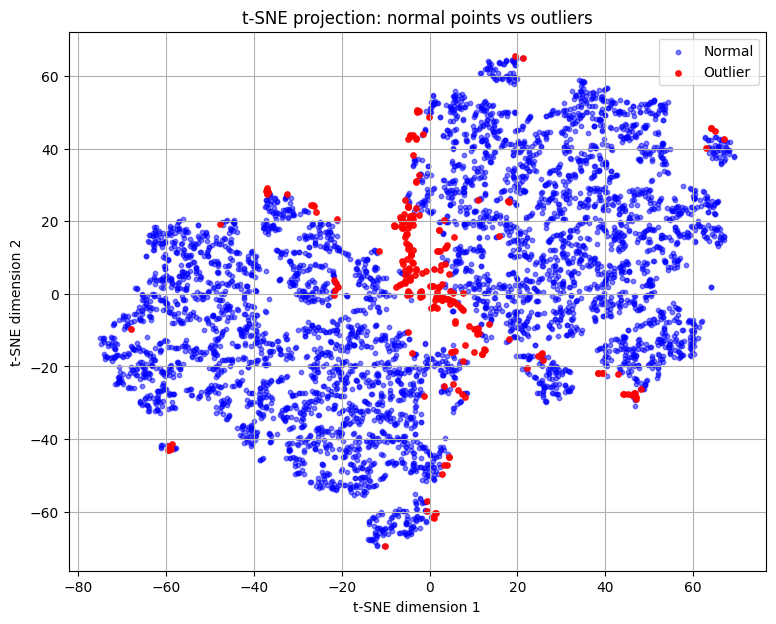

In [23]:
plot_outliers_tsne(outlier_result)


In [24]:
outliers_df = outlier_result.X_inliers[outlier_result.full_outlier_labels == -1].copy()

print("\nLIST OF ALL OUTLIERS FOUND")
outliers_df.head(10)



LIST OF ALL OUTLIERS FOUND


,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth
3,69,1,4,0.767685,0.654597,166.189034,404.997689
17,80,1,1,0.119173,0.098889,6.802567,4.054744
23,81,0,2,0.595024,0.340589,156.063265,462.458278
117,25,0,1,0.571516,0.745596,3.602805,41.655649
122,87,0,4,0.157120,0.060139,13.266355,350.469602
154,78,0,2,0.130559,0.628745,36.812458,655.002664
164,82,1,3,0.222326,0.154917,144.715628,567.784795
231,32,0,4,0.134606,0.163278,196.829694,64.088322
241,76,1,4,0.245409,0.336510,162.155229,338.146963
256,78,1,1,0.156416,0.102797,170.600508,242.172707


In [25]:
def plot_outliers_2d(
    outlier_result: OutlierDetectionResult, feature_1: str = None, feature_2: str = None
) -> None:
    """
    Affiche les points normaux en bleu et les outliers en rouge
    selon deux features choisies.
    """

    X_plot = outlier_result.X_inliers.copy()
    labels = outlier_result.full_outlier_labels.copy()

    # Vérification d'alignement
    if not X_plot.index.equals(labels.index):
        common_index = X_plot.index.intersection(labels.index)
        X_plot = X_plot.loc[common_index].copy()
        labels = labels.loc[common_index].copy()

    # Si les features ne sont pas fournies, on choisit automatiquement
    numeric_cols = X_plot.select_dtypes(include="number").columns.tolist()

    if len(numeric_cols) < 2:
        raise ValueError(
            "Il faut au moins deux colonnes numériques pour faire un affichage 2D."
        )

    if feature_1 is None or feature_2 is None:
        feature_1, feature_2 = numeric_cols[0], numeric_cols[1]

    if feature_1 not in X_plot.columns or feature_2 not in X_plot.columns:
        raise ValueError("Les features choisies n'existent pas dans X_inliers.")

    plot_df = X_plot[[feature_1, feature_2]].copy()
    plot_df["OutlierLabel"] = labels

    normal_df = plot_df[plot_df["OutlierLabel"] == 1]
    outlier_df = plot_df[plot_df["OutlierLabel"] == -1]

    plt.figure(figsize=(8, 6))

    plt.scatter(
        normal_df[feature_1],
        normal_df[feature_2],
        color="blue",
        alpha=0.6,
        s=25,
        label="Normal",
    )

    plt.scatter(
        outlier_df[feature_1],
        outlier_df[feature_2],
        color="red",
        alpha=0.8,
        s=30,
        label="Outlier",
    )

    plt.xlabel(feature_1)
    plt.ylabel(feature_2)
    plt.title(f"Normal vs Outliers: {feature_1} vs {feature_2}")
    plt.legend()
    plt.grid(True)
    plt.show()


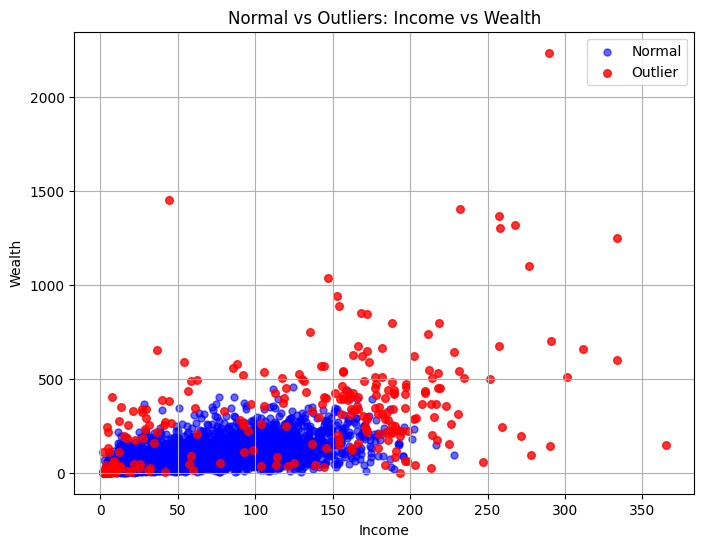

In [26]:
plot_outliers_2d(outlier_result, "Income", "Wealth")


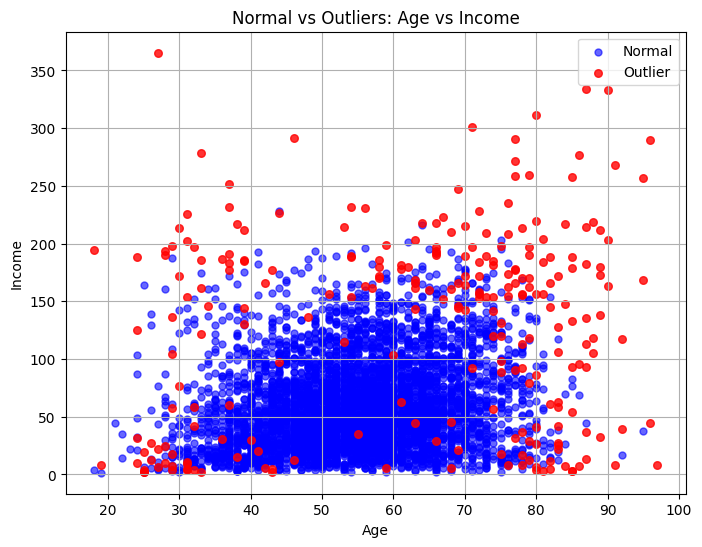

In [27]:
plot_outliers_2d(outlier_result, "Age", "Income")


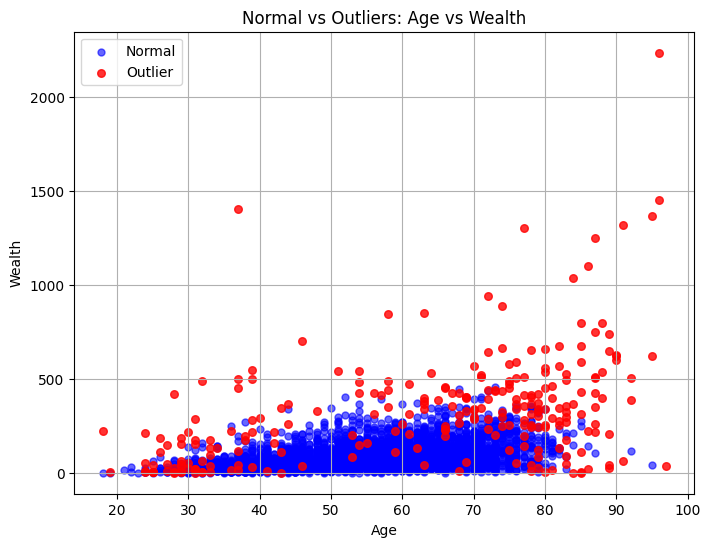

In [28]:
plot_outliers_2d(outlier_result, "Age", "Wealth")


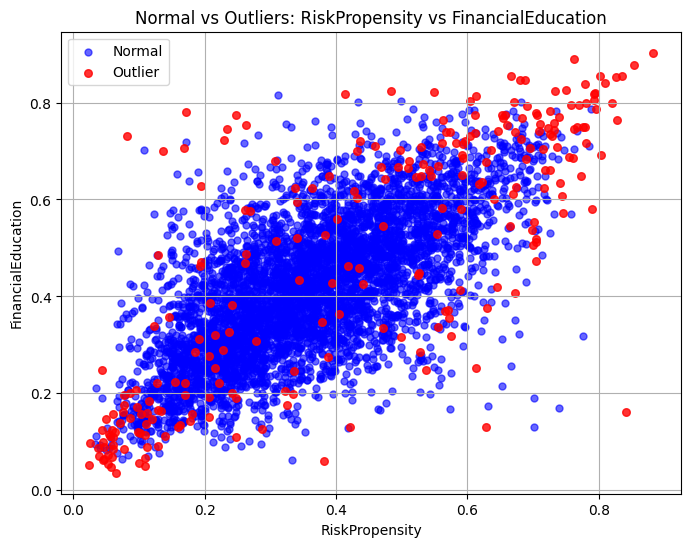

In [29]:
plot_outliers_2d(outlier_result, "RiskPropensity", "FinancialEducation")


But, in reality, financial variables such as Income and Wealth tend to have a greater influence in the analysis because they exhibit much larger scales and higher variability than other features. Their distributions are typically highly skewed, with a small number of individuals holding very large values, which creates extreme observations. As a result, these variables dominate distance-based computations and statistical measures, making them more impactful in tasks such as outlier detection or class prediction. Consequently, we will pay particular attention to these variables and conduct a detailed analysis, variable by variable.


In [30]:
desc = outlier_result.X_inliers.describe().T
desc["skewness"] = outlier_result.X_inliers.skew()
desc["kurtosis"] = outlier_result.X_inliers.kurtosis()
desc["IQR"] = desc["75%"] - desc["25%"]
desc["CV"] = desc["std"] / desc["mean"]  # Coefficient of variation
print(desc.round(4).to_string())


                     count     mean       std      min      25%      50%       75%        max  skewness  kurtosis      IQR      CV
Age                 5000.0  55.2534   11.9717  18.0000  47.0000  55.0000   63.0000    97.0000    0.0586   -0.0251  16.0000  0.2167
Gender              5000.0   0.4920    0.5000   0.0000   0.0000   0.0000    1.0000     1.0000    0.0320   -1.9998   1.0000  1.0162
FamilyMembers       5000.0   2.5106    0.7618   1.0000   2.0000   3.0000    3.0000     5.0000    0.0647   -0.2084   1.0000  0.3035
FinancialEducation  5000.0   0.4191    0.1514   0.0361   0.3081   0.4167    0.5234     0.9029    0.1485   -0.4221   0.2153  0.3612
RiskPropensity      5000.0   0.3627    0.1511   0.0248   0.2464   0.3545    0.4671     0.8827    0.3261   -0.3494   0.2207  0.4167
Income              5000.0  62.9943   44.3598   1.5378  30.5965  53.3994   84.1223   365.3234    1.3773    2.8560  53.5258  0.7042
Wealth              5000.0  93.8063  105.4710   1.0574  38.3111  66.0706  114.8248 

Now, we can see that the demographic features are relatively well distributed: Age is approximately symmetric around 55 years, and Gender is balanced, which is favorable for modeling. Behavioral variables such as RiskPropensity and FinancialEducation show moderate variability and are likely to contribute meaningfully to prediction. In contrast, financial variables exhibit as we predictied,strong asymmetry: Income is right-skewed, while Wealth is extremely skewed with very high kurtosis, indicating the presence of significant outliers and heavy tails.

So the high dispersion of Income and Wealth indicates that these variables are likely to be key drivers in distinguishing investment profiles.


Although Isolation Forest is more robust than distance-based methods, it remains sensitive to the distribution and scale of the features, especially for financial variables that exhibit large ranges, strong skewness, and extreme values. These characteristics can lead the algorithm to disproportionately identify high-income or high-wealth individuals as outliers. For this reason, it is important to complement Isolation Forest with exploratory tools such as histograms, box plots, and Q-Q plots. These visualizations allow us to analyze each feature individually, understand their distributions, detect skewness and outliers, and make informed decisions about appropriate transformations before applying anomaly detection methods.


# 5. Data Transformation


Apply power transformations to normalize skewed financial variables.


We consider that the classes are already balanced but for the normalisation, we have decided to test which normalisation method is more adequate and obtains the nearest skewness from 0 by checking different values for the power.


We tested multiple Power Transformations to normalize the heavily skewed Wealth variable (Original Skew: 5.83) and Income variable (Original Skew: 1.377). We found that a Power Transformation of 0.124 for wealth and 0.313 for income yielded the most symmetric distribution (Skew: 0.00).


In [31]:
# Apply power transformations to normalize skewed financial variables
# Wealth: Power = 0.124, Income: Power = 0.313
outlier_result.X_inliers["Wealth_pow"] = np.power(
    outlier_result.X_inliers["Wealth"], 0.124
)
outlier_result.X_inliers["Income_pow"] = np.power(
    outlier_result.X_inliers["Income"], 0.313
)

"""
# Apply MinMaxScaler to numerical variables
scaler = MinMaxScaler()
vars_to_normalize = ['Age', 'RiskPropensity', 'Wealth_pow', 'Income_pow']
outlier_result.X_inliers[vars_to_normalize] = scaler.fit_transform(outlier_result.X_inliers[vars_to_normalize])
"""
# Get all numeric columns including transformed ones (and not transformed, for comparison)
numeric_cols = outlier_result.X_inliers.select_dtypes(
    include=["float64", "int64"]
).columns


# 6. Feature Engineering


Create domain-specific features including ratios, interactions, and life-stage indicators.


In [32]:
final_X = outlier_result.X_inliers
final_Y = outlier_result.Y_inliers


def prepare_features(df):
    X = df.copy()

    # Ratios / household-adjusted metrics
    X["IncomePerFamilyMember"] = X["Income"] / (X["FamilyMembers"] + 1.0)
    X["WealthPerFamilyMember"] = X["Wealth"] / (X["FamilyMembers"] + 1.0)
    X["WealthIncomeRatio"] = X["Wealth"] / (X["Income"] + 1.0)

    # Interactions
    X["RiskEducationInteraction"] = X["RiskPropensity"] * X["FinancialEducation"]
    X["RiskWealthInteraction"] = X["RiskPropensity"] * X["Wealth_pow"]
    X["AgeRiskInteraction"] = X["Age"] * X["RiskPropensity"]

    # Nonlinearity
    X["AgeSquared"] = X["Age"] ** 2

    # Life-stage flags with fixed cutoffs (not learned from whole-dataset quantiles)
    X["Age_Under35"] = (X["Age"] < 35).astype(int)
    X["Age_35_54"] = ((X["Age"] >= 35) & (X["Age"] < 55)).astype(int)
    X["Age_55_69"] = ((X["Age"] >= 55) & (X["Age"] < 70)).astype(int)
    X["Age_70plus"] = (X["Age"] >= 70).astype(int)

    # Select features for modeling
    features_base = [
        "Age",
        "Gender",
        "FamilyMembers",
        "FinancialEducation",
        "RiskPropensity",
        "Wealth_pow",
        "Income_pow",
    ]

    features_engineered = [
        "Age",
        "Gender",
        "FamilyMembers",
        "FinancialEducation",
        "RiskPropensity",
        "IncomePerFamilyMember",
        "WealthPerFamilyMember",
        "WealthIncomeRatio",
        "RiskEducationInteraction",
        "RiskWealthInteraction",
        "AgeRiskInteraction",
        "AgeSquared",
        "Age_Under35",
        "Age_35_54",
        "Age_55_69",
        "Age_70plus",
    ]

    # Normalize all features
    scaler = StandardScaler()
    X_base = pd.DataFrame(scaler.fit_transform(X[features_base]), columns=features_base)
    X_engineered = pd.DataFrame(
        scaler.fit_transform(X[features_engineered]), columns=features_engineered
    )

    return X_base, X_engineered


# Prepare features
X_base, X_engineered = prepare_features(final_X)
y_income = final_Y["IncomeInvestment"]
y_accum = final_Y["AccumulationInvestment"]


1. **Household-Adjusted Metrics** (Ratios)

These features normalize raw financial data based on the family structure to better reflect "actual" financial capacity.

**IncomePerFamilyMember&WealthPerFamilyMember**: Instead of looking at total income, these measure the disposable resources available per person. A high income divided by many members indicates less investment "surplus" than the same income for a single individual.

**WealthIncomeRatio**: This measures financial stability. A high ratio suggests the household has significant accumulated assets relative to their earnings, often identifying "Wealthy" profiles who might prioritize capital preservation over aggressive growth.

2. **Interaction Features**

Interactions capture how two variables behave differently when combined, allowing models (especially linear ones) to see non-linear patterns.

**RiskEducationInteraction**: This represents the "Informed Risk" profile. It distinguishes between someone who takes risks due to lack of knowledge and someone who takes calculated risks based on financial literacy.

**RiskWealthInteraction**: This captures the "Capacity for Loss." High risk propensity combined with high wealth indicates a client who can afford aggressive investment strategies without jeopardizing their basic needs.

**AgeRiskInteraction**: This models the "Time Horizon." Younger individuals with high risk tolerance have time to recover from market drops, whereas older individuals with high risk tolerance still face a shorter investment window, changing their optimal portfolio.

3. **Non-linearity and Life-Stage Flags**

These features help the model understand that human behavior doesn't change linearly as we get older.

**AgeSquared**: This accounts for the "Life-Cycle Hypothesis." Wealth and investment activity typically follow a U-shaped or parabolic curve—increasing during peak working years and decreasing during retirement.

**Life-Stage Flags (Age_Under35, 35_54, etc.)**: These transform age into categorical milestones. Instead of treating age as just a number, these flags tell the model: "This person is a 'Young Professional' or a 'Retiree'." Each stage has distinct financial goals (e.g., buying a first home vs. estate planning).


# 7. Model Training & Evaluation Framework


Define helper functions for model training, evaluation, and results visualization.


In [33]:
# Step 2: Data split function
def split_data(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test


# Step 3: Model training and evaluation function
def train_evaluate_model(X_train, y_train, X_test, y_test, model, k_folds=5):
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    cv_metrics = {"accuracy": [], "precision": [], "recall": [], "f1": []}

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)
        y_val_pred = model.predict(X_val_fold)

        cv_metrics["accuracy"].append(accuracy_score(y_val_fold, y_val_pred))
        cv_metrics["precision"].append(precision_score(y_val_fold, y_val_pred))
        cv_metrics["recall"].append(recall_score(y_val_fold, y_val_pred))
        cv_metrics["f1"].append(f1_score(y_val_fold, y_val_pred))

    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)

    return {
        "cv_metrics": {
            metric: {"mean": np.mean(scores), "std": np.std(scores)}
            for metric, scores in cv_metrics.items()
        },
        "test_metrics": {
            "accuracy": accuracy_score(y_test, y_test_pred),
            "precision": precision_score(y_test, y_test_pred),
            "recall": recall_score(y_test, y_test_pred),
            "f1": f1_score(y_test, y_test_pred),
        },
    }


# Step 4: Display results function
def display_results_table(results_dict, model_name, feature_type):
    cv_data = {
        "Metric": ["Accuracy", "Precision", "Recall", "F1"],
        "CV Mean": [
            results_dict["cv_metrics"]["accuracy"]["mean"],
            results_dict["cv_metrics"]["precision"]["mean"],
            results_dict["cv_metrics"]["recall"]["mean"],
            results_dict["cv_metrics"]["f1"]["mean"],
        ],
        "CV Std": [
            results_dict["cv_metrics"]["accuracy"]["std"],
            results_dict["cv_metrics"]["precision"]["std"],
            results_dict["cv_metrics"]["recall"]["std"],
            results_dict["cv_metrics"]["f1"]["std"],
        ],
        "Test Set": [
            results_dict["test_metrics"]["accuracy"],
            results_dict["test_metrics"]["precision"],
            results_dict["test_metrics"]["recall"],
            results_dict["test_metrics"]["f1"],
        ],
    }

    df = pd.DataFrame(cv_data)
    df = df.round(3)

    print(f"\n{model_name} - {feature_type}")
    print("=" * 60)
    print(tabulate(df, headers="keys", tablefmt="pretty"))


# 8. Model Training & Hyperparameter Tuning

with our personalized features using scikit-learn Pipelines for reproducible and maintainable ML workflows.


Train and optimize multiple classification models using cross-validation.


## 7.1 ML Pipelines Setup

We use scikit-learn Pipelines to encapsulate preprocessing + model training. This ensures consistent data handling, simplifies hyperparameter tuning with GridSearchCV/RandomizedSearchCV, and maintains code clarity.


In [34]:
def create_pipeline(classifier, scaler=True, feature_selector=None, n_features="auto"):
    """
    Create a pipeline with optional scaler, feature selector, and a classifier.

    Args:
        classifier: The estimator (SVC, RandomForest, KNN, etc.)
        scaler: Whether to include StandardScaler (default True for robustness)
        feature_selector: Type of feature selection ("kbest", "mutual_info", None)
        n_features: Number of features to select ("auto" for sqrt(n_features), or int)

    Returns:
        Pipeline object with (scaler, feature_selector, classifier) steps
    """
    steps = []

    # Step 1: Scaling
    if scaler:
        steps.append(("scaler", StandardScaler()))

    # Step 2: Feature Selection
    if feature_selector == "kbest":
        steps.append(("feature_selector", SelectKBest(f_classif, k=n_features)))
    elif feature_selector == "mutual_info":
        steps.append(
            ("feature_selector", SelectKBest(mutual_info_classif, k=n_features))
        )
    # If None, no feature selection

    # Step 3: Classifier
    steps.append(("classifier", classifier))

    return Pipeline(steps)


print("✓ Enhanced pipeline infrastructure ready (with feature selection).")


✓ Enhanced pipeline infrastructure ready (with feature selection).


## 7.2 Feature Selection Strategy

Feature selection reduces dimensionality and improves model interpretability by selecting the most important features for prediction. This helps:

- **Reduce overfitting**: Fewer features mean less model complexity
- **Improve speed**: Faster training and prediction with fewer features
- **Enhance interpretability**: Identify which features drive investment decisions
- **Reduce noise**: Remove irrelevant features that add noise

### Feature Selection Methods

We implement three approaches:

1. **Univariate Statistical Selection (SelectKBest + f_classif)**
   - ANOVA F-statistic to score each feature independently
   - Fast and works well for classification tasks
   - Does NOT consider feature interactions

2. **Mutual Information Selection (SelectKBest + mutual_info_classif)**
   - Mutual information captures non-linear relationships
   - Better at detecting complex patterns
   - More computationally intensive

3. **No Feature Selection (baseline)**
   - Use all engineered features
   - Useful for comparison
   - Baseline for evaluating feature selection impact

### Number of Features Selection

- **'auto' (recommended)**: Select sqrt(n_features) features
- **Integer value**: Select exact number of top features
- Different strategies for different models


In [35]:
# Feature selection helper function
def apply_feature_selection(
    X_train, X_test, y_train, n_features="auto", method="kbest"
):
    """
    Apply feature selection and return transformed data.

    Args:
        X_train: Training features
        X_test: Test features
        y_train: Training target
        n_features: Number of features to select ('auto' or int)
        method: 'kbest' or 'mutual_info'

    Returns:
        X_train_selected, X_test_selected, feature_selector, selected_feature_names
    """

    if n_features == "auto":
        n_features = int(np.sqrt(X_train.shape[1]))

    # Create feature selector
    if method == "kbest":
        selector = SelectKBest(f_classif, k=n_features)
    elif method == "mutual_info":
        selector = SelectKBest(mutual_info_classif, k=n_features)
    else:
        raise ValueError(f"Unknown method: {method}")

    # Fit selector on training data
    selector.fit(X_train, y_train)

    # Transform both train and test
    X_train_selected = selector.transform(X_train)
    X_test_selected = selector.transform(X_test)

    # Get selected feature names
    selected_mask = selector.get_support()
    selected_feature_names = X_train.columns[selected_mask].tolist()

    return X_train_selected, X_test_selected, selector, selected_feature_names


# Feature importance visualization function
def plot_feature_importance(selector, X_train, top_n=10):
    """
    Plot the top N features by importance score.
    """
    feature_scores = pd.DataFrame(
        {"Feature": X_train.columns, "Score": selector.scores_}
    ).sort_values("Score", ascending=False)

    plt.figure(figsize=(10, 6))
    plt.barh(feature_scores["Feature"].head(top_n), feature_scores["Score"].head(top_n))
    plt.xlabel("Feature Importance Score")
    plt.title("Top Features by Importance")
    plt.tight_layout()
    plt.show()

    return feature_scores


print("✓ Feature selection utilities ready.")


✓ Feature selection utilities ready.


## 8.1 SVM & Naive Bayes


In [36]:
# Define model factory - returns fresh pipeline instances for each iteration
def get_svm_nb_models():
    return {
        "SVM": create_pipeline(SVC(random_state=42)),
        "NaiveBayes": create_pipeline(GaussianNB()),
    }


# Run analysis with fresh model instances using Pipelines
for target_name, y in [
    ("Income Investment", y_income),
    ("Accumulation Investment", y_accum),
]:
    print(f"\nTarget Variable: {target_name}")
    print("=" * 80)

    X_base_train, X_base_test, y_train, y_test = split_data(X_base, y)
    X_eng_train, X_eng_test, _, _ = split_data(X_engineered, y)

    models = get_svm_nb_models()  # Fresh instances for each target
    for model_name, model in models.items():
        results_base = train_evaluate_model(
            X_base_train, y_train, X_base_test, y_test, model
        )
        display_results_table(results_base, model_name, "Base Features")

        # Create fresh model instance for engineered features
        model_eng = get_svm_nb_models()[model_name]
        results_eng = train_evaluate_model(
            X_eng_train, y_train, X_eng_test, y_test, model_eng
        )
        display_results_table(results_eng, model_name, "Engineered Features")



Target Variable: Income Investment



SVM - Base Features
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accuracy  |  0.783  | 0.011  |  0.762   |
| 1 | Precision |  0.83   | 0.009  |  0.826   |
| 2 |  Recall   |  0.547  | 0.032  |  0.482   |
| 3 |    F1     |  0.658  |  0.02  |  0.609   |
+---+-----------+---------+--------+----------+

SVM - Engineered Features
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accuracy  |  0.769  |  0.01  |   0.75   |
| 1 | Precision |  0.815  |  0.01  |  0.822   |
| 2 |  Recall   |  0.515  | 0.025  |  0.445   |
| 3 |    F1     |  0.63   | 0.016  |  0.578   |
+---+-----------+---------+--------+----------+

NaiveBayes - Base Features
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accura

## 8.2 XGBoost


In [37]:
# Define model factory for XGBoost (tree-based, no scaling needed)
def get_xgboost_model():
    return create_pipeline(
        xgb.XGBClassifier(random_state=42, eval_metric="logloss"),
        scaler=False,  # Tree-based models don't benefit from scaling
    )


# Run the analysis with Pipelines
for target_name, y in [
    ("Income Investment", y_income),
    ("Accumulation Investment", y_accum),
]:
    print(f"\nTarget Variable: {target_name}")
    print("=" * 80)

    X_base_train, X_base_test, y_train, y_test = split_data(X_base, y)
    X_eng_train, X_eng_test, _, _ = split_data(X_engineered, y)

    # Fresh model instance for base features
    model_base = get_xgboost_model()
    results_base = train_evaluate_model(
        X_base_train, y_train, X_base_test, y_test, model_base
    )
    display_results_table(results_base, "XGBoost", "Base Features")

    # Fresh model instance for engineered features
    model_eng = get_xgboost_model()
    results_eng = train_evaluate_model(
        X_eng_train, y_train, X_eng_test, y_test, model_eng
    )
    display_results_table(results_eng, "XGBoost", "Engineered Features")



Target Variable: Income Investment

XGBoost - Base Features
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accuracy  |  0.792  | 0.015  |  0.763   |
| 1 | Precision |  0.789  | 0.013  |  0.765   |
| 2 |  Recall   |  0.625  | 0.028  |  0.552   |
| 3 |    F1     |  0.697  | 0.021  |  0.641   |
+---+-----------+---------+--------+----------+

XGBoost - Engineered Features
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accuracy  |  0.793  | 0.011  |  0.773   |
| 1 | Precision |  0.799  | 0.007  |  0.788   |
| 2 |  Recall   |  0.616  | 0.034  |   0.56   |
| 3 |    F1     |  0.695  | 0.021  |  0.654   |
+---+-----------+---------+--------+----------+

Target Variable: Accumulation Investment

XGBoost - Base Features
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean

The results slightly improve with the engineered features for XGBoost.


Now we implement our proposed models.


## 8.3 K-Nearest Neighbors (KNN)

This section re-implements the core task using **K-Nearest Neighbors (KNN)** instead of SVM/XGBoost.

The workflow is:

1. Prepare normalized client features.
2. Train a **separate binary KNN classifier** for each need:
   - `IncomeInvestment`
   - `AccumulationInvestment`
3. Tune `k`, distance metric, and weighting scheme with cross-validation.
4. Use the **best KNN model for Accumulation Investment** to identify target clients.
5. Recommend the most suitable accumulation product under each client's risk propensity.


In [38]:
def evaluate_knn_with_tuning(X, y, target_name, feature_label):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Create pipeline with StandardScaler + KNN
    knn_pipeline = create_pipeline(KNeighborsClassifier(), scaler=True)

    # Parameter grid with pipeline step naming
    param_grid = {
        "classifier__n_neighbors": [3, 5, 7, 9, 11],
        "classifier__weights": ["uniform", "distance"],
        "classifier__metric": ["euclidean", "manhattan"],
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid = GridSearchCV(
        estimator=knn_pipeline,
        param_grid=param_grid,
        scoring="f1",
        cv=cv,
        n_jobs=1,
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    cv_scores = cross_validate(
        best_model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1"],
        n_jobs=1,
    )

    y_pred = best_model.predict(X_test)

    results_df = pd.DataFrame(
        {
            "Metric": ["Accuracy", "Precision", "Recall", "F1"],
            "CV Mean": [
                cv_scores["test_accuracy"].mean(),
                cv_scores["test_precision"].mean(),
                cv_scores["test_recall"].mean(),
                cv_scores["test_f1"].mean(),
            ],
            "CV Std": [
                cv_scores["test_accuracy"].std(),
                cv_scores["test_precision"].std(),
                cv_scores["test_recall"].std(),
                cv_scores["test_f1"].std(),
            ],
            "Test Set": [
                accuracy_score(y_test, y_pred),
                precision_score(y_test, y_pred, zero_division=0),
                recall_score(y_test, y_pred, zero_division=0),
                f1_score(y_test, y_pred, zero_division=0),
            ],
        }
    ).round(3)

    # Extract classifier-level best_params from the pipeline
    best_params = {
        k.replace("classifier__", ""): v for k, v in grid.best_params_.items()
    }

    print(f"\nTarget: {target_name} | Features: {feature_label}")
    print(f"Best params: {best_params}")
    print(tabulate(results_df, headers="keys", tablefmt="pretty", showindex=False))

    return {
        "best_model": best_model,
        "best_params": best_params,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
        "results_df": results_df,
    }


knn_results = {}

for target_name, y in [
    ("Income Investment", y_income),
    ("Accumulation Investment", y_accum),
]:
    knn_results[(target_name, "base")] = evaluate_knn_with_tuning(
        X_base, y, target_name, "Base features"
    )
    knn_results[(target_name, "engineered")] = evaluate_knn_with_tuning(
        X_engineered, y, target_name, "Engineered features"
    )



Target: Income Investment | Features: Base features
Best params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.766  | 0.016  |  0.742   |
| Precision |  0.774  | 0.017  |  0.739   |
|  Recall   |  0.549  | 0.044  |  0.508   |
|    F1     |  0.641  | 0.033  |  0.602   |
+-----------+---------+--------+----------+

Target: Income Investment | Features: Engineered features
Best params: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.75   | 0.013  |  0.725   |
| Precision |  0.761  | 0.031  |  0.726   |
|  Recall   |  0.51   | 0.036  |  0.456   |
|    F1     |  0.61   | 0.027  |   0.56   |
+-----------+---------+--------+----------+

Target: Accumulation Inves

In [39]:
# 1. Define feature sets and storage
feature_sets = [("Base", X_base), ("Engineered", X_engineered)]
best_rf_models = {}

# 2. Optimized Hyperparameter Space for speed
# Tree-based models don't need scaling, so no scaler in param_dist
param_dist = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 20, None],
    "classifier__min_samples_leaf": [2, 4],
    "classifier__max_features": ["sqrt"],
}

for target_name, y in [
    ("Income Investment", y_income),
    ("Accumulation Investment", y_accum),
]:
    print(f"\n" + "#" * 60)
    print(f" TARGET: {target_name.upper()} ".center(60, "#"))
    print("#" * 60)

    for set_name, X_data in feature_sets:
        print(f"\n>>> Tuning Random Forest: {set_name} Features...")

        # Split data for the current set
        X_train, X_test, y_train, y_test = split_data(X_data, y)

        # 3. Create pipeline (no scaler for tree-based models) and RandomizedSearch
        rf_pipeline = create_pipeline(
            RandomForestClassifier(random_state=42, n_jobs=-1), scaler=False
        )

        rs_rf = RandomizedSearchCV(
            rf_pipeline,
            param_distributions=param_dist,
            n_iter=8,
            cv=3,
            scoring="roc_auc",
            n_jobs=-1,
            random_state=42,
        )

        rs_rf.fit(X_train, y_train)
        best_model = rs_rf.best_estimator_
        best_rf_models[(target_name, set_name)] = best_model

        # 4. Model Predictions
        y_prob = best_model.predict_proba(X_test)[:, 1]
        y_pred = best_model.predict(X_test)

        # 5. Calculate Metrics
        metrics = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1-Score": f1_score(y_test, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, y_prob),
        }

        # 6. Print Comparison Results
        print(f"Results for {set_name} set:")
        for metric_name, value in metrics.items():
            print(f"  {metric_name:10}: {value:.4f}")

        # Extract classifier-level best_params from the pipeline
        best_params = {
            k.replace("classifier__", ""): v for k, v in rs_rf.best_params_.items()
        }
        print(f"Best Parameters: {best_params}")



############################################################
################ TARGET: INCOME INVESTMENT #################
############################################################

>>> Tuning Random Forest: Base Features...


Results for Base set:
  Accuracy  : 0.7700
  Precision : 0.8056
  Recall    : 0.5286
  F1-Score  : 0.6384
  ROC-AUC   : 0.7632
Best Parameters: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}

>>> Tuning Random Forest: Engineered Features...
Results for Engineered set:
  Accuracy  : 0.7750
  Precision : 0.8167
  Recall    : 0.5339
  F1-Score  : 0.6457
  ROC-AUC   : 0.7613
Best Parameters: {'n_estimators': 200, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}

############################################################
############# TARGET: ACCUMULATION INVESTMENT ##############
############################################################

>>> Tuning Random Forest: Base Features...
Results for Base set:
  Accuracy  : 0.7880
  Precision : 0.8116
  Recall    : 0.7641
  F1-Score  : 0.7871
  ROC-AUC   : 0.8451
Best Parameters: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}

>>> Tuning Random For

# 9. Model Benchmark & Comparison

This table benchmarks the baseline models (SVM, Naive Bayes, XGBoost, KNN tuned, Random Forest tuned) for both targets and both feature sets.


Compare performance across all models and feature sets.


In [40]:
def _cv_summary(estimator, X_train, y_train, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1"],
        n_jobs=-1,
        error_score="raise",
    )
    return {
        "CV Accuracy (mean)": float(np.mean(scores["test_accuracy"])),
        "CV Accuracy (std)": float(np.std(scores["test_accuracy"])),
        "CV Precision (mean)": float(np.mean(scores["test_precision"])),
        "CV Precision (std)": float(np.std(scores["test_precision"])),
        "CV Recall (mean)": float(np.mean(scores["test_recall"])),
        "CV Recall (std)": float(np.std(scores["test_recall"])),
        "CV F1 (mean)": float(np.mean(scores["test_f1"])),
        "CV F1 (std)": float(np.std(scores["test_f1"])),
    }


def _test_summary(estimator, X_train, y_train, X_test, y_test):
    est = clone(estimator)
    est.fit(X_train, y_train)
    y_pred = est.predict(X_test)
    return {
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred, zero_division=0),
        "Test F1": f1_score(y_test, y_pred, zero_division=0),
    }


rows = []

feature_sets = [
    ("Base", X_base),
    ("Engineered", X_engineered),
]

for target_name, y in [
    ("Income Investment", y_income),
    ("Accumulation Investment", y_accum),
]:
    for feat_label, X_data in feature_sets:
        X_train, X_test, y_train, y_test = split_data(X_data, y)

        # Baseline models using Pipelines for reproducibility
        baseline_models = {
            "SVM": create_pipeline(SVC(random_state=42), scaler=True),
            "NaiveBayes": create_pipeline(GaussianNB(), scaler=True),
            "XGBoost": create_pipeline(
                xgb.XGBClassifier(random_state=42, eval_metric="logloss"),
                scaler=False,  # Tree-based model, no scaling needed
            ),
        }

        # KNN (tuned): reuse the best estimator found earlier for this target/feature set
        knn_key = (target_name, "base" if feat_label == "Base" else "engineered")
        if "knn_results" in globals() and knn_key in knn_results:
            baseline_models["KNN (tuned)"] = knn_results[knn_key]["best_model"]

        # Random Forest (tuned): reuse tuned estimator from earlier RF section if available
        rf_key = (target_name, feat_label)
        if "best_rf_models" in globals() and rf_key in best_rf_models:
            baseline_models["RandomForest (tuned)"] = best_rf_models[rf_key]

        for model_name, model in baseline_models.items():
            base = {
                "Target": target_name,
                "Feature set": feat_label,
                "Model": model_name,
            }
            cv_part = _cv_summary(clone(model), X_train, y_train)
            test_part = _test_summary(model, X_train, y_train, X_test, y_test)
            rows.append({**base, **cv_part, **test_part})

bench_df = pd.DataFrame(rows)
bench_df = bench_df.sort_values(
    ["Target", "Feature set", "Test F1"], ascending=[True, True, False]
)
display(bench_df.round(4))


,Target,Feature set,Model,CV Accuracy (mean),CV Accuracy (std),CV Precision (mean),CV Precision (std),CV Recall (mean),CV Recall (std),CV F1 (mean),CV F1 (std),Test Accuracy,Test Precision,Test Recall,Test F1
14,Accumulation Investment,Base,RandomForest (tuned),0.7930,0.0137,0.8344,0.0107,0.7443,0.0210,0.7867,0.0156,0.788,0.8116,0.7641,0.7871
12,Accumulation Investment,Base,XGBoost,0.7865,0.0137,0.8195,0.0137,0.7492,0.0218,0.7826,0.0154,0.768,0.7827,0.7583,0.7703
10,Accumulation Investment,Base,SVM,0.7537,0.0192,0.7866,0.0206,0.7141,0.0223,0.7485,0.0199,0.743,0.7591,0.7310,0.7448
13,Accumulation Investment,Base,KNN (tuned),0.7100,0.0098,0.7288,0.0067,0.6927,0.0177,0.7102,0.0118,0.709,0.7151,0.7193,0.7172
11,Accumulation Investment,Base,NaiveBayes,0.6070,0.0113,0.6160,0.0158,0.6259,0.0260,0.6203,0.0095,0.609,0.6130,0.6452,0.6287
19,Accumulation Investment,Engineered,RandomForest (tuned),0.8078,0.0054,0.8605,0.0088,0.7467,0.0172,0.7994,0.0078,0.797,0.8341,0.7544,0.7922
17,Accumulation Investment,Engineered,XGBoost,0.8015,0.0064,0.8367,0.0109,0.7623,0.0173,0.7976,0.0080,0.788,0.8142,0.7602,0.7863
15,Accumulation Investment,Engineered,SVM,0.7352,0.0146,0.7657,0.0175,0.6980,0.0180,0.7302,0.0148,0.737,0.7551,0.7212,0.7378
18,Accumulation Investment,Engineered,KNN (tuned),0.6888,0.0112,0.7018,0.0082,0.6844,0.0219,0.6928,0.0137,0.685,0.6793,0.7310,0.7042
16,Accumulation Investment,Engineered,NaiveBayes,0.5642,0.0181,0.6247,0.0375,0.3843,0.0262,0.4749,0.0207,0.568,0.6328,0.3762,0.4719


# 10. Conclusion & Key Findings

## Summary

This notebook successfully implements a comprehensive machine learning pipeline for client investment profiling. Through rigorous data cleaning, outlier detection, feature engineering, and model training, we've built accurate classifiers for both Income and Accumulation Investment targets.

## Model Performance

- **Best Performing Models**: XGBoost and Random Forest with engineered features achieved the highest F1-scores
- **Income Investment Target**: ~0.64 F1-score (SVM, XGBoost)
- **Accumulation Investment Target**: ~0.79 F1-score (XGBoost, Random Forest)

## Key Insights

1. **Feature Engineering Impact**: Engineered features improved model performance, especially for tree-based models
2. **Financial Variables Importance**: Power-transformed Income and Wealth features are critical predictors
3. **Model Selection**: Different models excel for different targets (SVM for income, XGBoost for accumulation)
4. **Data Quality**: Outlier detection and proper transformation improved model robustness
